
Complete Grover's Algorithm Hamming Weight Experiment Suite
============================================================

Tests Grover's algorithm under amplitude damping noise for:
- 2-qubit (|11⟩) with 1× and 3× gate inflation
- 3-qubit (|000⟩ and |111⟩) with 1× and 3× gate inflation
- All four noise types independently: amplitude, phase, depolarizing, readout

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler
from qiskit_aer.noise import (
    NoiseModel,
    amplitude_damping_error,
    phase_damping_error,
    depolarizing_error,
    ReadoutError
)
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, List, Tuple
import json

RUNNING COMPLETE EXPERIMENTAL SUITE
Noise strength: 0.1, Shots: 4096

2q_1x_11:
  Circuit depth: 8 layers
    none           : P(|11⟩) = 1.0000
    amplitude      : P(|11⟩) = 0.5391
    phase          : P(|11⟩) = 0.7563
    depolarizing   : P(|11⟩) = 0.8638
    readout        : P(|11⟩) = 0.8142

2q_3x_11:
  Circuit depth: 20 layers
    none           : P(|11⟩) = 1.0000
    amplitude      : P(|11⟩) = 0.3669
    phase          : P(|11⟩) = 0.6514
    depolarizing   : P(|11⟩) = 0.8572
    readout        : P(|11⟩) = 0.8125

3q_1x_000:
  Circuit depth: 26 layers
    none           : P(|000⟩) = 0.9426
    amplitude      : P(|000⟩) = 0.2200
    phase          : P(|000⟩) = 0.2698
    depolarizing   : P(|000⟩) = 0.6653
    readout        : P(|000⟩) = 0.6890

3q_1x_111:
  Circuit depth: 22 layers
    none           : P(|111⟩) = 0.9480
    amplitude      : P(|111⟩) = 0.1057
    phase          : P(|111⟩) = 0.3101
    depolarizing   : P(|111⟩) = 0.6577
    readout        : P(|111⟩) = 0.6785

3q_3x_0

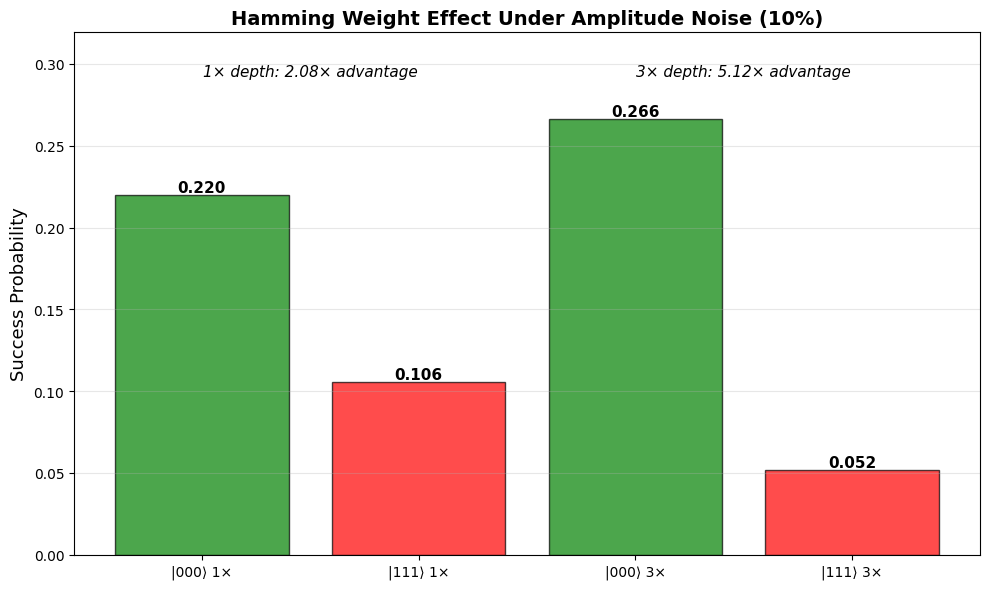

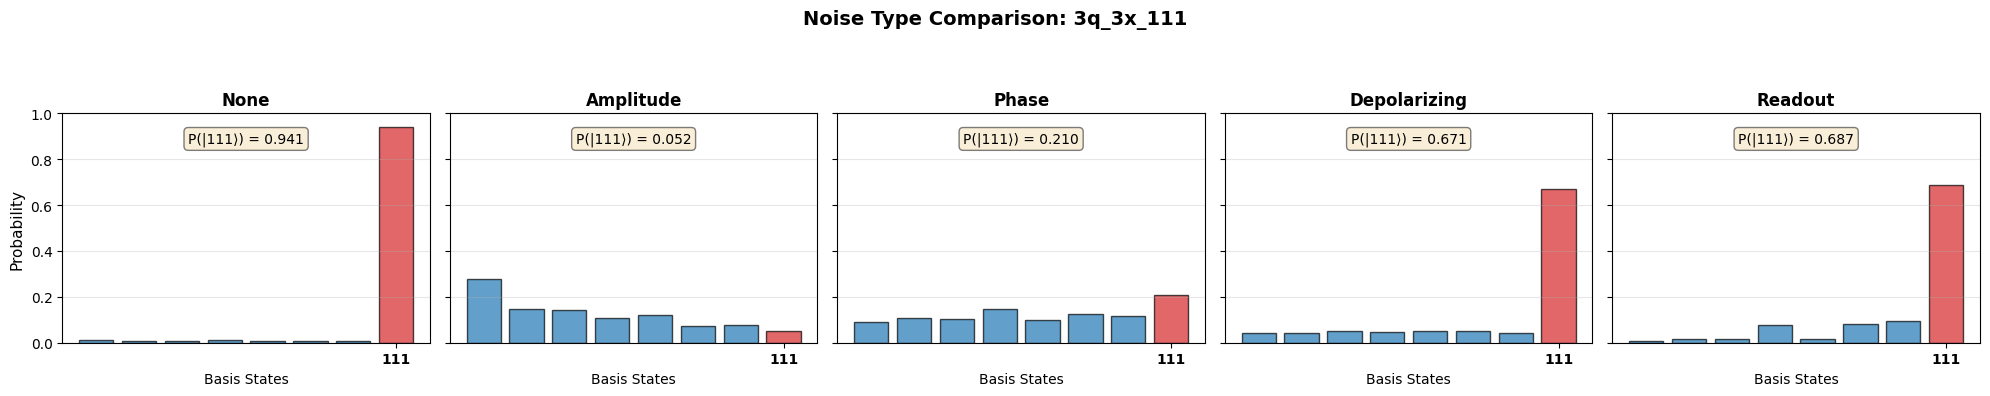

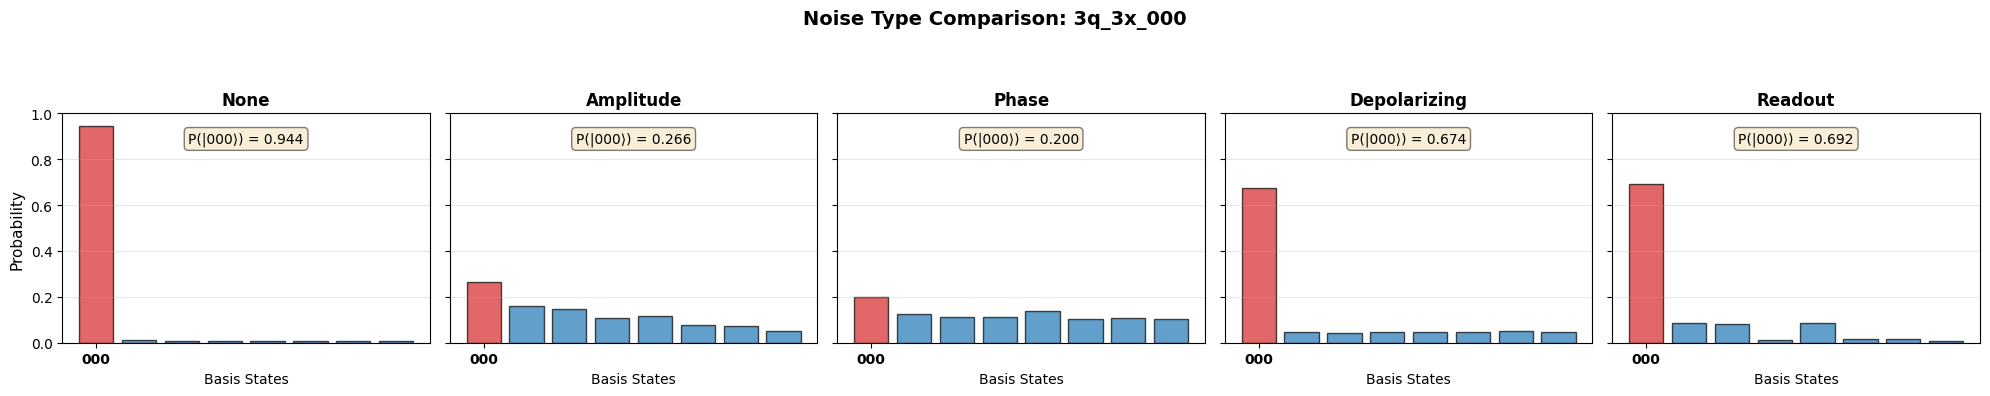

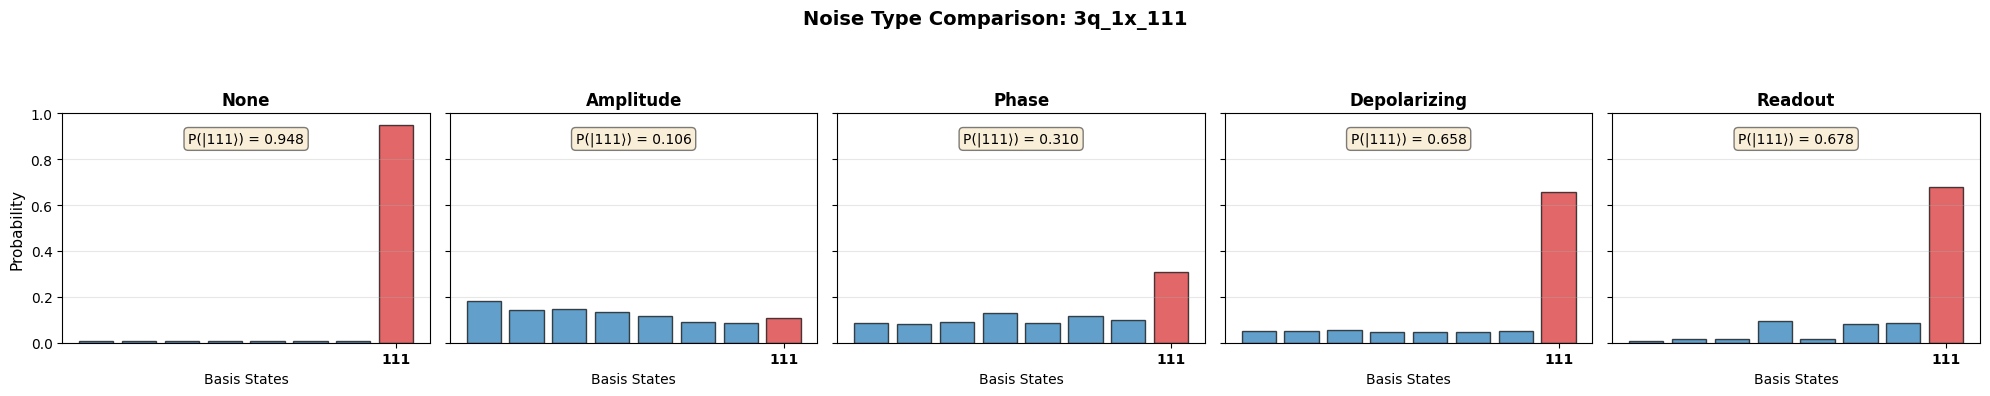

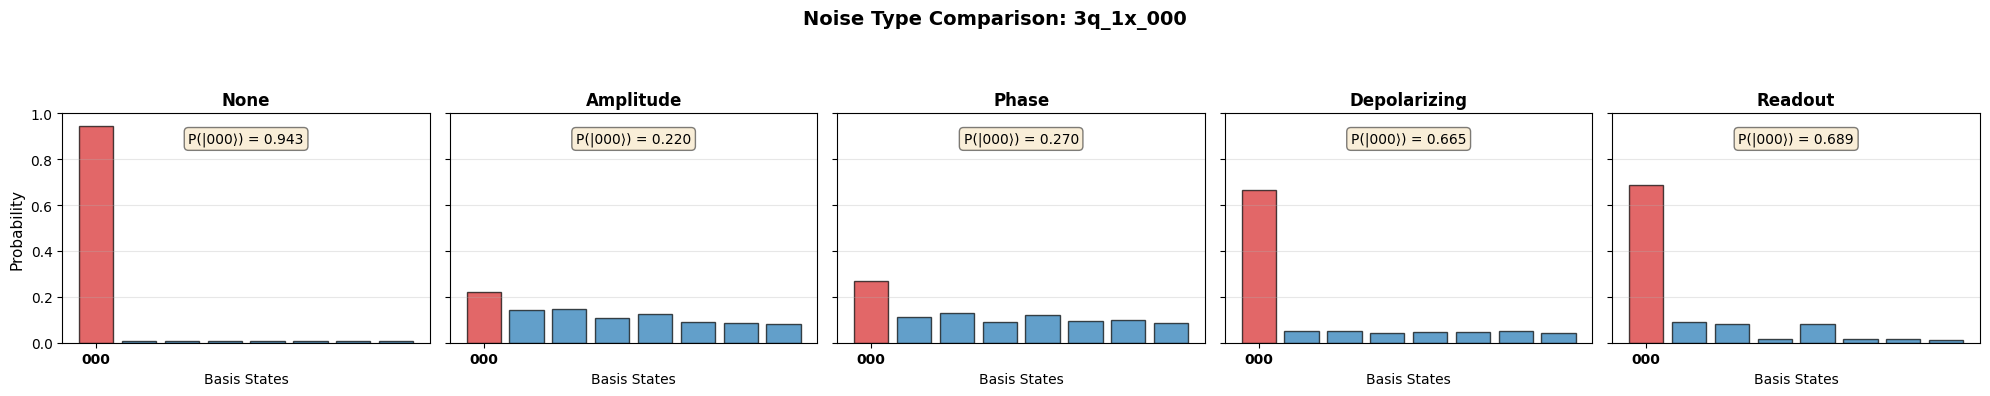

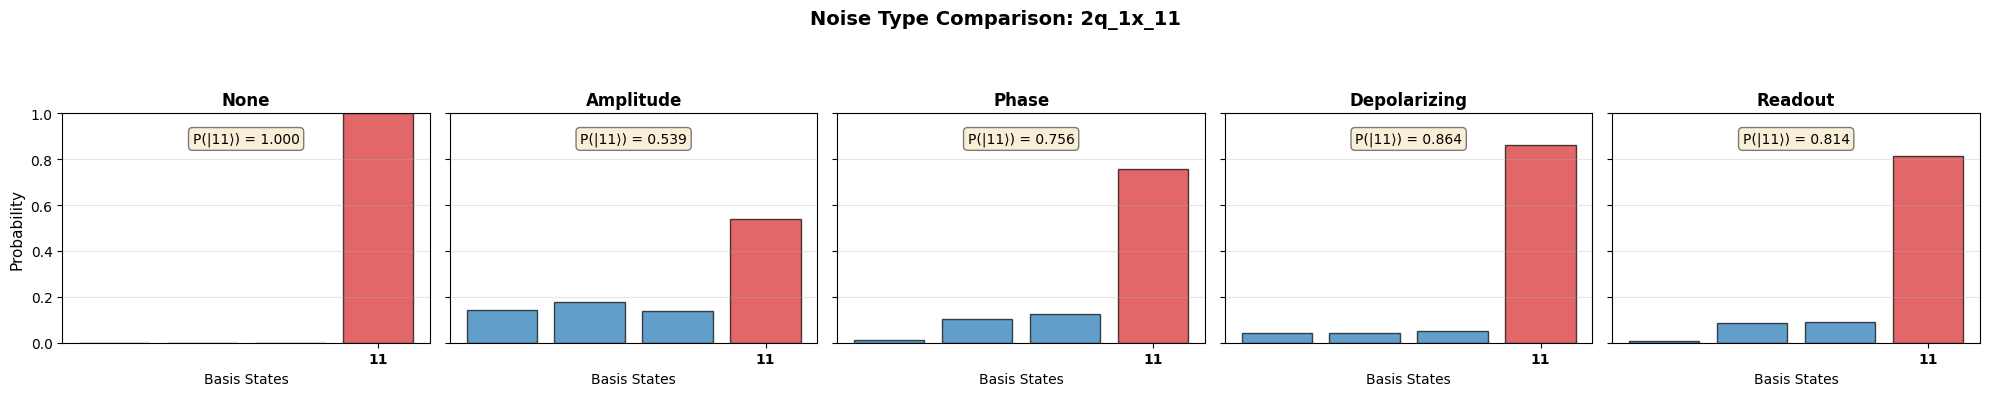

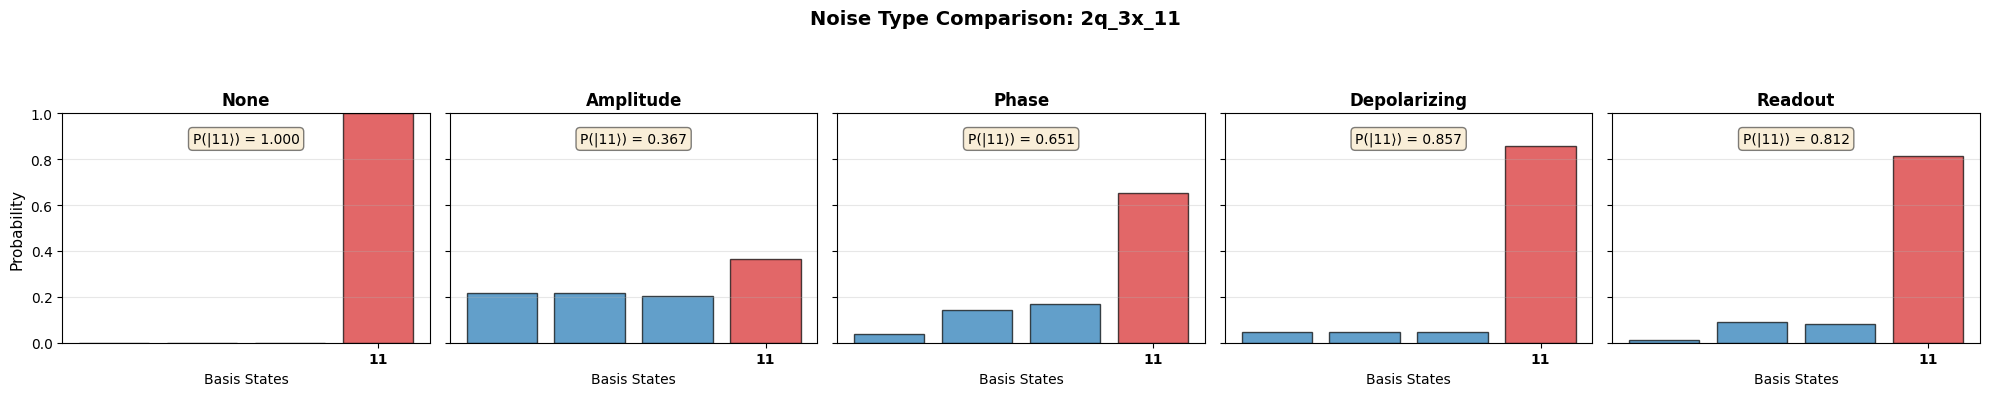

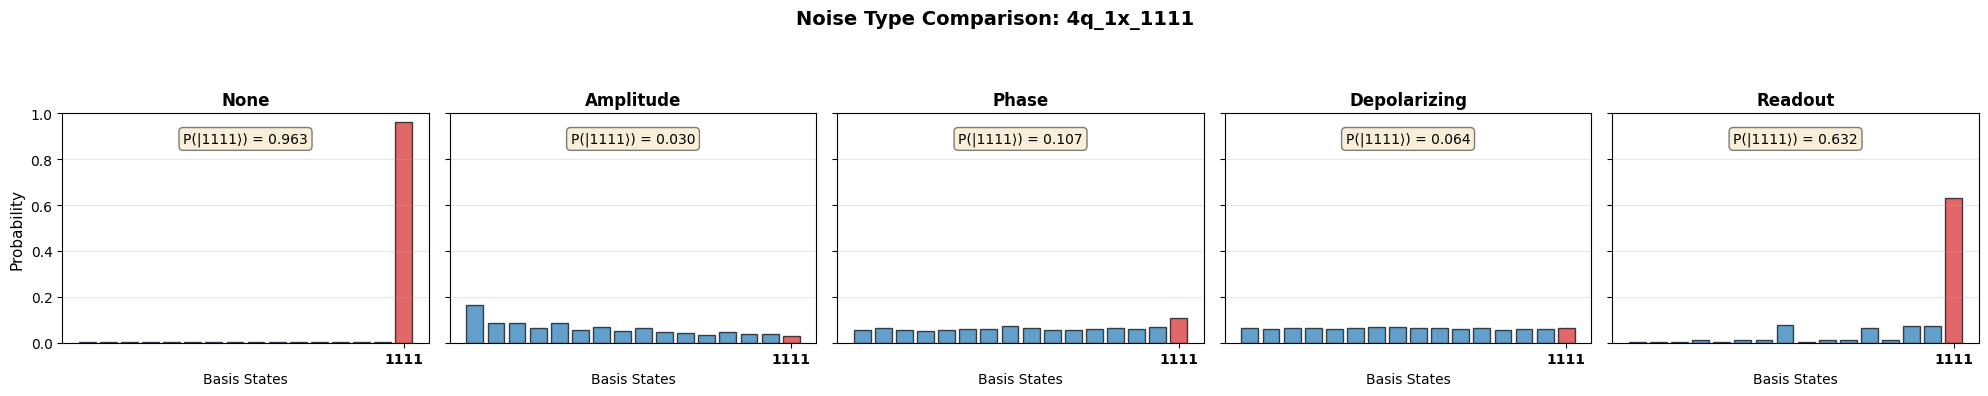


✓ All experiments completed successfully!


In [ ]:

# =============================================================================
# NOISE MODEL CREATION
# =============================================================================

def create_noise_model(noise_type='none', noise_strength=0.1):
    """
    Create noise model with specified type.
    
    Args:
        noise_type: 'amplitude', 'phase', 'depolarizing', 'readout', or 'none'
        noise_strength: probability parameter (default 0.1)
    
    Returns:
        NoiseModel object
    """
    noise_model = NoiseModel()
    
    if noise_type == 'amplitude':
        amp_error = amplitude_damping_error(noise_strength)
        noise_model.add_all_qubit_quantum_error(amp_error, ['u3', 'u2', 'u1', 'u', 'h', 'x'])
    
    elif noise_type == 'phase':
        phase_error = phase_damping_error(noise_strength)
        noise_model.add_all_qubit_quantum_error(phase_error, ['u3', 'u2', 'u1', 'u', 'h', 'x'])

    elif noise_type == 'depolarizing':
        cx_error = depolarizing_error(noise_strength, 2)
        ccx_error = depolarizing_error(noise_strength, 3)
        noise_model.add_all_qubit_quantum_error(cx_error, ['cx'])
        noise_model.add_all_qubit_quantum_error(ccx_error, ['ccx'])

    elif noise_type == 'readout':
        readout_error = ReadoutError([
            [1 - noise_strength, noise_strength],
            [noise_strength, 1 - noise_strength]
        ])
        noise_model.add_all_qubit_readout_error(readout_error)
    
    return noise_model

# =============================================================================
# 2-QUBIT CIRCUITS (|11⟩)
# =============================================================================

def create_2qubit_grover_1x():
    """Standard 2-qubit Grover searching for |11⟩"""
    qc = QuantumCircuit(2, 2)
    
    # Initialize
    qc.h([0, 1])
    
    # Oracle: CZ marks |11⟩
    qc.cz(0, 1)
    
    # Diffuser
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])
    
    qc.measure([0, 1], [0, 1])
    return qc

def create_2qubit_grover_3x():
    """3× gate-inflated 2-qubit Grover searching for |11⟩"""
    qc = QuantumCircuit(2, 2)
    
    # Triple H initialization
    for q in [0, 1]:
        qc.h(q)
        qc.h(q)
        qc.h(q)
    
    # Oracle with padding
    qc.cz(0, 1)
    qc.id([0, 1])
    qc.id([0, 1])
    
    # Diffuser
    for q in [0, 1]:
        qc.h(q)
        qc.h(q)
        qc.h(q)
    
    qc.x([0, 1])
    qc.id([0, 1])
    qc.id([0, 1])
    
    qc.cz(0, 1)
    qc.id([0, 1])
    qc.id([0, 1])
    
    qc.x([0, 1])
    
    for q in [0, 1]:
        qc.h(q)
        qc.h(q)
        qc.h(q)
    
    qc.measure([0, 1], [0, 1])
    return qc

# =============================================================================
# 3-QUBIT CIRCUITS (|000⟩ and |111⟩)
# =============================================================================

def oracle_111(qc):
    """Oracle marking |111⟩"""
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)

def oracle_000(qc):
    """Oracle marking |000⟩"""
    qc.x([0, 1, 2])
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    qc.x([0, 1, 2])

def diffuser_3q(qc):
    """Standard 3-qubit diffuser"""
    qc.h([0, 1, 2])
    qc.x([0, 1, 2])
    oracle_111(qc)
    qc.x([0, 1, 2])
    qc.h([0, 1, 2])

def create_3qubit_grover_1x(target='111'):
    """
    Standard 3-qubit Grover with 2 iterations
    
    Args:
        target: '111' or '000'
    """
    qc = QuantumCircuit(3, 3)
    
    # Initialize
    qc.h([0, 1, 2])
    
    # 2 Grover iterations
    for _ in range(2):
        if target == '111':
            oracle_111(qc)
        else:
            oracle_000(qc)
        diffuser_3q(qc)
    
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

def oracle_111_tripled(qc):
    """Triple-inflated oracle marking |111⟩"""
    qc.h(2)
    qc.h(2)
    qc.h(2)
    
    qc.ccx(0, 1, 2)
    qc.id([0, 1, 2])
    qc.id([0, 1, 2])
    
    qc.h(2)
    qc.h(2)
    qc.h(2)

def oracle_000_tripled(qc):
    """Triple-inflated oracle marking |000⟩"""
    qc.x([0, 1, 2])
    qc.id([0, 1, 2])
    qc.id([0, 1, 2])
    
    qc.h(2)
    qc.h(2)
    qc.h(2)
    
    qc.ccx(0, 1, 2)
    qc.id([0, 1, 2])
    qc.id([0, 1, 2])
    
    qc.h(2)
    qc.h(2)
    qc.h(2)
    
    qc.x([0, 1, 2])
    qc.id([0, 1, 2])
    qc.id([0, 1, 2])

def diffuser_3q_tripled(qc):
    """Triple-inflated 3-qubit diffuser"""
    for q in [0, 1, 2]:
        qc.h(q)
        qc.h(q)
        qc.h(q)
    
    qc.x([0, 1, 2])
    qc.id([0, 1, 2])
    qc.id([0, 1, 2])
    
    qc.h(2)
    qc.h(2)
    qc.h(2)
    
    qc.ccx(0, 1, 2)
    qc.id([0, 1, 2])
    qc.id([0, 1, 2])
    
    qc.h(2)
    qc.h(2)
    qc.h(2)
    
    qc.x([0, 1, 2])
    
    for q in [0, 1, 2]:
        qc.h(q)
        qc.h(q)
        qc.h(q)

def create_3qubit_grover_3x(target='111'):
    """
    3× gate-inflated 3-qubit Grover with 2 iterations
    
    Args:
        target: '111' or '000'
    """
    qc = QuantumCircuit(3, 3)
    
    # Triple H initialization
    for q in [0, 1, 2]:
        qc.h(q)
        qc.h(q)
        qc.h(q)
    
    # 2 Grover iterations
    for _ in range(2):
        if target == '111':
            oracle_111_tripled(qc)
        else:
            oracle_000_tripled(qc)
        diffuser_3q_tripled(qc)
    
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

def create_4qubit_grover_1x_1111():
    qc = QuantumCircuit(4, 4)

    # Initialize
    qc.h(range(4))

    # Oracle
    def oracle_1111(qc):
        qc.h(3)
        qc.mcx([0, 1, 2], 3)
        qc.h(3)

    def diffuser_4q(qc):
        qc.h(range(4))
        qc.x(range(4))
        oracle_1111(qc)
        qc.x(range(4))
        qc.h(range(4))

    # 3 Grover iterations
    for _ in range(3):
        oracle_1111(qc)
        diffuser_4q(qc)

    qc.measure(range(4), range(4))
    return qc


# =============================================================================
# EXECUTION AND ANALYSIS
# =============================================================================

def run_circuit(qc, noise_type='none', noise_strength=0.1, shots=4096):
    """
    Run circuit with specified noise model
    
    Returns:
        Dictionary of probabilities
    """
    noise_model = create_noise_model(noise_type, noise_strength)
    sim = AerSimulator(noise_model=noise_model)
    
    tqc = transpile(qc,sim,optimization_level=0)
    result = sim.run(tqc, shots=shots).result()

    counts = result.get_counts()
    
    # Convert to probabilities
    probs = {state: count / shots for state, count in counts.items()}
    
    return probs

def run_all_experiments(noise_strength=0.1, shots=4096):
    """
    Run complete experimental suite
    
    Returns:
        Nested dictionary: experiments[config][noise_type] = probabilities
    """
    configs = {
        '2q_1x_11': create_2qubit_grover_1x(),
        '2q_3x_11': create_2qubit_grover_3x(),
        '3q_1x_000': create_3qubit_grover_1x('000'),
        '3q_1x_111': create_3qubit_grover_1x('111'),
        '3q_3x_000': create_3qubit_grover_3x('000'),
        '3q_3x_111': create_3qubit_grover_3x('111'),
        '4q_1x_1111': create_4qubit_grover_1x_1111(),
    }
    
    noise_types = ['none', 'amplitude', 'phase', 'depolarizing', 'readout']
    
    results = {}
    
    print("="*80)
    print("RUNNING COMPLETE EXPERIMENTAL SUITE")
    print(f"Noise strength: {noise_strength}, Shots: {shots}")
    print("="*80)
    
    for config_name, qc in configs.items():
        print(f"\n{config_name}:")
        print(f"  Circuit depth: {qc.depth()} layers")
        
        results[config_name] = {}
        
        for noise_type in noise_types:
            probs = run_circuit(qc, noise_type, noise_strength, shots)
            results[config_name][noise_type] = probs
            
            # Determine target state
            if config_name.startswith('2q'):
                target = '11'
            elif config_name.startswith('3q'):
                target = '000' if '000' in config_name else '111'
            elif config_name.startswith('4q'):
                target = '1111'
            else:
                raise ValueError(f"Unknown config: {config_name}")

            
            success_prob = probs.get(target, 0.0)
            
            print(f"    {noise_type:15s}: P(|{target}⟩) = {success_prob:.4f}")
    
    return results

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_hamming_comparison(results, noise_type='amplitude'):
    """
    Create comparison plot for |000⟩ vs |111⟩ at 1× and 3× depths
    """
    configs = ['3q_1x_000', '3q_1x_111', '3q_3x_000', '3q_3x_111']
    targets = ['000', '111', '000', '111']
    labels = ['|000⟩ 1×', '|111⟩ 1×', '|000⟩ 3×', '|111⟩ 3×']
    
    success_probs = []
    for config, target in zip(configs, targets):
        probs = results[config][noise_type]
        success_probs.append(probs.get(target, 0.0))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['green' if '000' in label else 'red' for label in labels]
    bars = ax.bar(labels, success_probs, color=colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for bar, val in zip(bars, success_probs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel('Success Probability', fontsize=13)
    ax.set_title(f'Hamming Weight Effect Under {noise_type.capitalize()} Noise (10%)', 
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(success_probs) * 1.2)
    ax.grid(axis='y', alpha=0.3)
    
    # Add annotations
    ratio_1x = success_probs[0] / success_probs[1] if success_probs[1] > 0 else 0
    ratio_3x = success_probs[2] / success_probs[3] if success_probs[3] > 0 else 0
    
    ax.text(0.5, max(success_probs) * 1.1, 
            f'1× depth: {ratio_1x:.2f}× advantage',
            ha='center', fontsize=11, style='italic')
    ax.text(2.5, max(success_probs) * 1.1, 
            f'3× depth: {ratio_3x:.2f}× advantage',
            ha='center', fontsize=11, style='italic')
    
    plt.tight_layout()
    return fig

def plot_noise_comparison(results, config):
    """
    Compare all noise types for a single configuration.
    Supports 2q, 3q, and 4q circuits.
    """
    noise_types = ['none', 'amplitude', 'phase', 'depolarizing', 'readout']

    # --- Determine target and qubit count ---
    if config.startswith('2q'):
        n_qubits = 2
        target = '11'
    elif config.startswith('3q'):
        n_qubits = 3
        target = '000' if '000' in config else '111'
    elif config.startswith('4q'):
        n_qubits = 4
        target = '1111'
    else:
        raise ValueError(f"Unknown config: {config}")

    fig, axes = plt.subplots(
        1, len(noise_types),
        figsize=(4 * len(noise_types), 4),
        sharey=True
    )

    states = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
    target_idx = states.index(target)

    for ax, noise_type in zip(axes, noise_types):
        probs = results[config][noise_type]
        values = [probs.get(state, 0.0) for state in states]
        colors = ['tab:red' if state == target else 'tab:blue' for state in states]

        ax.bar(range(len(states)), values, color=colors, alpha=0.7, edgecolor='black')

        # ---- CLEAN AXIS LABELING ----
        ax.set_xticks([target_idx])
        ax.set_xticklabels([target], fontsize=10, fontweight='bold')

        ax.set_title(noise_type.capitalize(), fontsize=12, fontweight='bold')
        ax.set_xlabel('Basis States', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 1)

        success = probs.get(target, 0.0)
        ax.text(
            0.5, 0.92,
            f'P(|{target}⟩) = {success:.3f}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )

    axes[0].set_ylabel('Probability', fontsize=11)
    fig.suptitle(
        f'Noise Type Comparison: {config}',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    return fig



def create_summary_table(results):
    """
    Create pandas DataFrame summarizing all results
    """
    data = []
    
    for config_name in results.keys():
        # Parse config name
        parts = config_name.split('_')
        qubits = parts[0]
        depth = parts[1]
        target = parts[2]
        
        for noise_type in results[config_name].keys():
            probs = results[config_name][noise_type]
            
            # Get success probability
            if qubits == '2q':
                success = probs.get('11', 0.0)
                hamming_weight = 2
            elif target == '000':
                success = probs.get('000', 0.0)
                hamming_weight = 0
            elif target == '1111':
                success = probs.get('0000',0.0)
                hamming_weight = 4
            else:
                success = probs.get('111', 0.0)
                hamming_weight = 3
            
            data.append({
                'Qubits': qubits,
                'Depth': depth,
                'Target': target,
                'Hamming_Weight': hamming_weight,
                'Noise_Type': noise_type,
                'Success_Probability': success
            })
    
    df = pd.DataFrame(data)
    return df

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    # Run all experiments
    results = run_all_experiments(noise_strength=0.1, shots=4096)
    
    # Save results to JSON
    with open('grover_hamming_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    print("\n✓ Results saved to grover_hamming_results.json")
    
    # Create summary table
    df = create_summary_table(results)
    df.to_csv('grover_hamming_summary.csv', index=False)
    print("✓ Summary table saved to grover_hamming_summary.csv")
    
    # Print key findings
    print("\n" + "="*80)
    print("KEY FINDINGS")
    print("="*80)
    
    # Hamming weight effect under amplitude damping
    amp_results = df[df['Noise_Type'] == 'amplitude']
    
    print("\nAmplitude Damping - Hamming Weight Effect:")
    for depth in ['1x', '3x']:
        depth_data = amp_results[amp_results['Depth'] == depth]
        p_000 = depth_data[depth_data['Target'] == '000']['Success_Probability'].values
        p_111 = depth_data[depth_data['Target'] == '111']['Success_Probability'].values
        
        if len(p_000) > 0 and len(p_111) > 0:
            ratio = p_000[0] / p_111[0] if p_111[0] > 0 else float('inf')
            print(f"  {depth} depth: |000⟩ = {p_000[0]:.4f}, |111⟩ = {p_111[0]:.4f}, "
                  f"Ratio = {ratio:.2f}×")
    
    # Generate plots
    print("\n" + "="*80)
    print("GENERATING PLOTS")
    print("="*80)
    
    # --- Hamming weight comparison ---
    fig = plot_hamming_comparison(results, noise_type='amplitude')
    fig.savefig(
        'hamming_weight_comparison.png',
        dpi=300,
        bbox_inches='tight'
    )
    print("✓ Saved: hamming_weight_comparison.png")


    # --- Noise-type comparisons (basis-state distributions) ---
    noise_comparison_configs = [
        '3q_3x_111',
        '3q_3x_000',
        '3q_1x_111',
        '3q_1x_000',
        '2q_1x_11',
        '2q_3x_11',
        '4q_1x_1111',
    ]

    for config in noise_comparison_configs:
        fig = plot_noise_comparison(results, config)
        filename = f'noise_type_comparison_{config}.png'
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {filename}")
    
    plt.show()
    
    print("\n✓ All experiments completed successfully!")